<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/HC_ICG_Delineation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook explores the ICG delineation methods in literature and performs Pearson's test on the different signals from HeartCycle database.

# Load Data

In [ ]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from google.colab import drive
from scipy.stats import pearsonr

In [ ]:
# mount Google Drive
drive.mount('/content/drive')
dir_path = "/content/drive/MyDrive/TFG/Data_HeartCycle/59146237"

# # list files
# files = os.listdir(dir_path)
# print("\nAvailable files:")
# for i, file in enumerate(files):
#     print(f"{i}: {file}")

# # file selection
# file_index = int(input("\nEnter file number: "))
# file_path = os.path.join(dir_path, files[file_index])

file_path = '/content/drive/MyDrive/TFG/Data_HeartCycle/59146237/59146237_s0000005.mat'
data_hc = sio.loadmat(file_path)
print(data_hc.keys())

header = data_hc['__header__']
#print(header)
#b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Thu Mar 12 19:36:31 2009'

version = data_hc['__version__']
#print(version)
# 1.0

globals = data_hc['__globals__']
#print(globals)
# []

measures = data_hc['measure']
#print(measures)

print(type(measures))        # ndarray
print(measures.shape)       # 30 rows and 5 columns

rows, cols = measures.shape # measures is a 30x5 ndarray
# to find out how many signals we have
for i in range(rows):
    for j in range(cols):
        try:
            label = measures[i, j]['label'][0, 0]
            print(f"{label} = measures[{i},{j}]")
        except:
            continue

print(measures[1,1]['label'][0]) #ICG

Mounted at /content/drive
dict_keys(['__header__', '__version__', '__globals__', 'measure'])
<class 'numpy.ndarray'>
(30, 5)
['Event'] = measures[0,0]
['ECG'] = measures[0,1]
['ECG'] = measures[0,2]
['ECG'] = measures[0,3]
['ECG'] = measures[0,4]
['SPO2'] = measures[1,0]
['IMP'] = measures[1,1]
['PCG'] = measures[1,2]
['ECHO'] = measures[1,3]
['PPG'] = measures[1,4]
['O/C'] = measures[2,0]
['RPEAKS'] = measures[2,1]
['RPEAKS'] = measures[2,2]
['RPEAKS'] = measures[2,3]
['RPEAKS'] = measures[2,4]
['Load'] = measures[3,0]
['AVO'] = measures[3,1]
['AVO'] = measures[3,2]
['AVO'] = measures[3,3]
['AVO'] = measures[3,4]
['HPD'] = measures[4,0]
['PPEjec'] = measures[4,1]
['PEP'] = measures[4,2]
['PEP'] = measures[4,3]
['PEP'] = measures[4,4]
['DC'] = measures[5,0]
['AVC'] = measures[5,1]
['AVC'] = measures[5,2]
['AVC'] = measures[5,3]
['AVC'] = measures[5,4]
['TFC'] = measures[6,0]
['LVET'] = measures[6,1]
['LVET'] = measures[6,2]
['LVET'] = measures[6,3]
['LVET'] = measures[6,4]
['FC'] = mea

If we overlay the bandpassed ICG and the SG ICG we see they overlap, suggesting that SG is not actually helping.
We used SG as a smoothing filter:
- It smooths out high-frequency noise, it preserves local shape, but it may flatten sharp peaks
- We're replacing the signal with a smoothed version

The Savitzky-Golay filter is a smoothing filter based on local polynomial regression. Instead of simply averaging neighboring points (like a moving average does), SG fits a polynomial curve to a small window of the data, and replaces the center point with the value predicted by that polynomial

# Signal Preprocessing (ICG, ECG)

## ICG Preprocessing

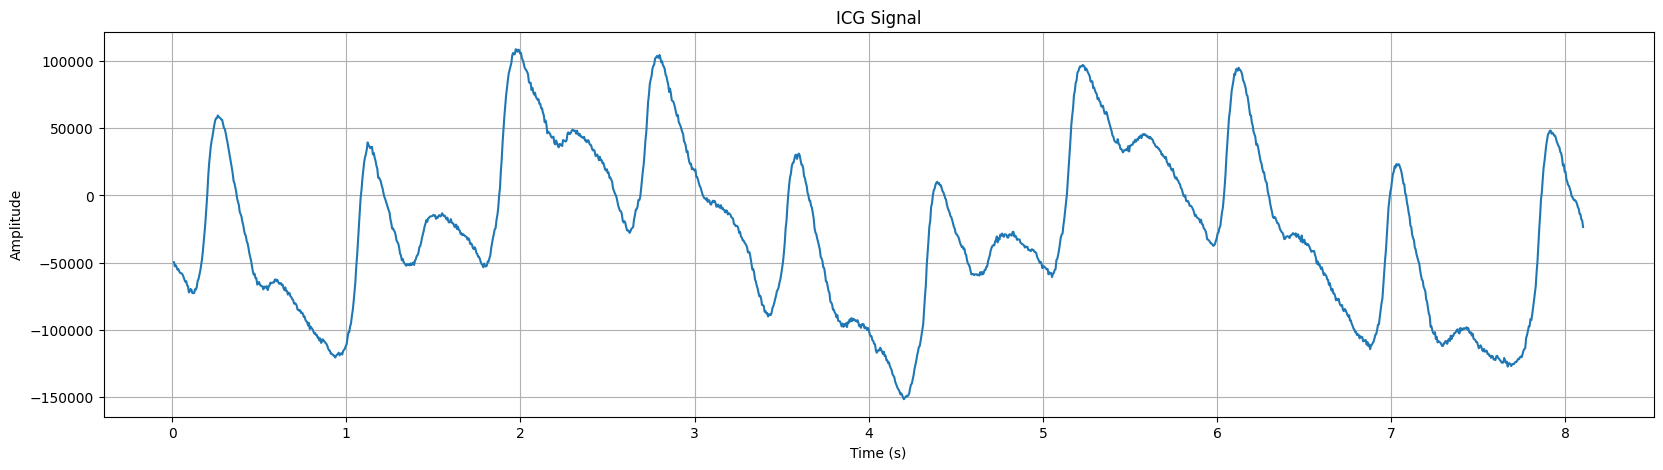

In [ ]:
icg = measures[1,1] #extract the ICG signal
icg_time = icg['time'][0,0].flatten()
icg_data = icg['data'][0,0].flatten()

plt.figure(figsize=(20, 5))
plt.plot(icg_time, icg_data)
plt.title('ICG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Band pass filtering

In [ ]:
dt = np.mean(np.diff(icg_time))      #time step, we calculate the average interval between consecutive time samples
fs = 1 / dt                          #sampling frequency
print(fs) #198.45387059502093

198.71124064372685


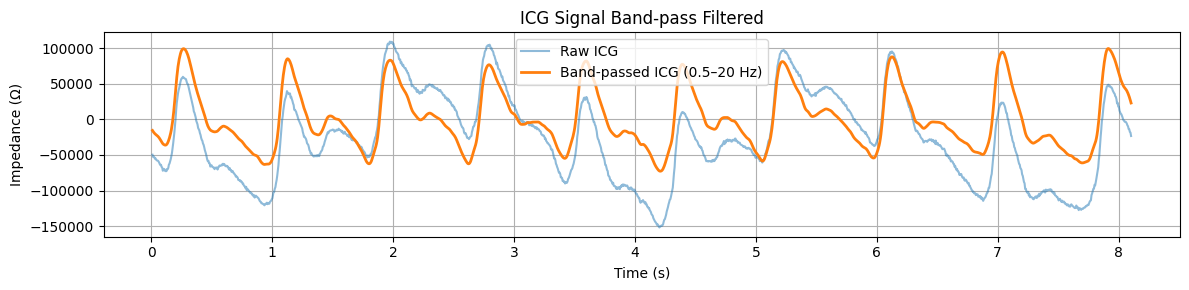

In [ ]:
def bandpass(signal, fs, lowcut, highcut, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)
icg_bandpassed = bandpass(icg_data, fs,0.5,20)

plt.figure(figsize=(12, 3))
plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.5)
plt.plot(icg_time, icg_bandpassed, label='Band-passed ICG (0.5–20 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Impedance (Ω)')
plt.title('ICG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Baseline removal

The Savitzky-Golay filter is a smoothing filter based on local polynomial regression. Instead of simply averaging neighboring points (like a moving average does), SG fits a polynomial curve to a small window of the data, and replaces the center point with the value predicted by that polynomial.

We use SG to estimate the low-frequency trend (baseline), and then subtract it. Here, SG is not used to smooth the signal but to isolate the low-frequency component (like respiration or motion drift).

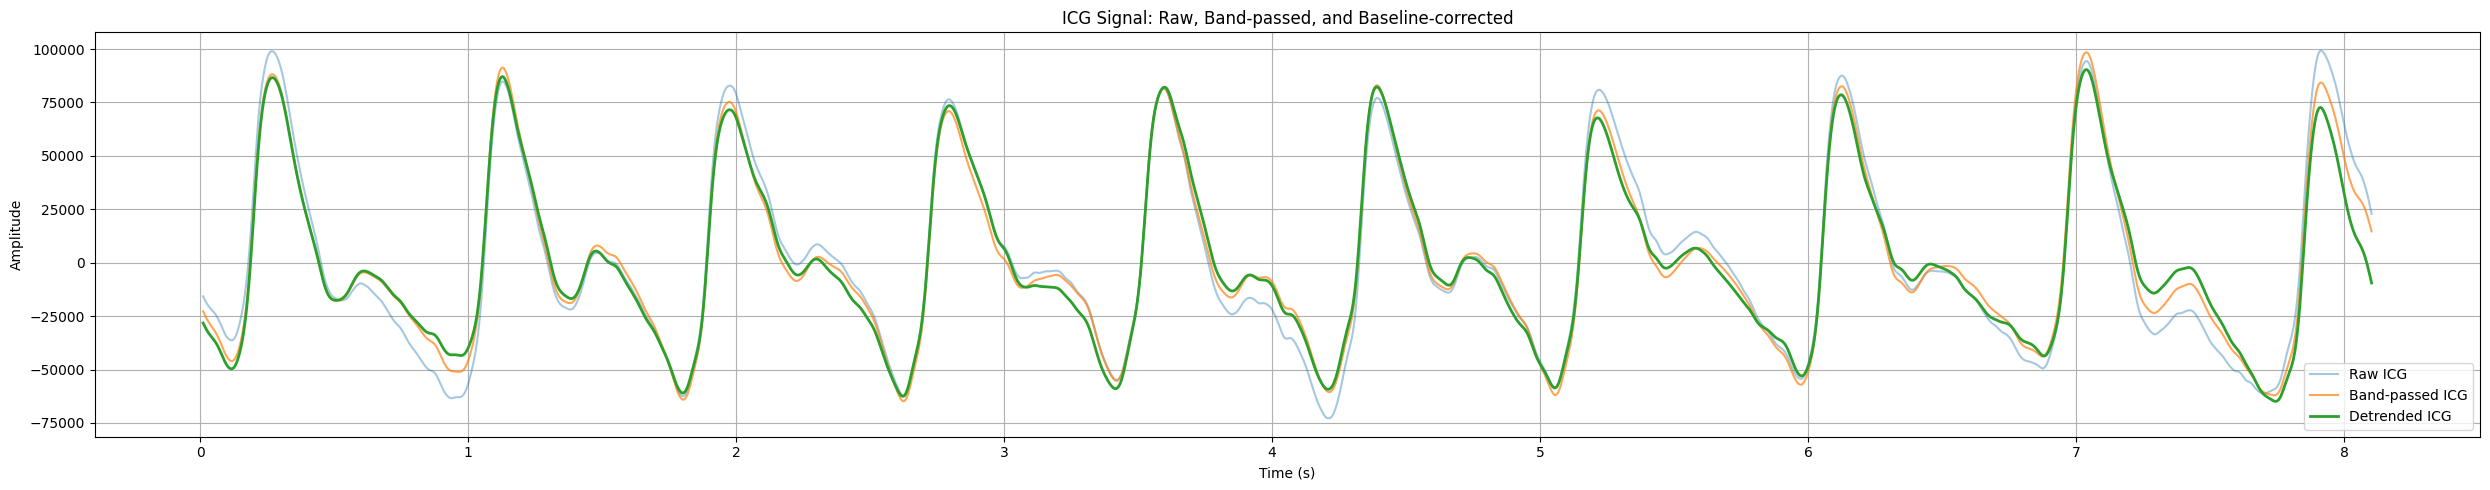

Text(0.5, 1.0, 'Preprocessed ICG Signal')

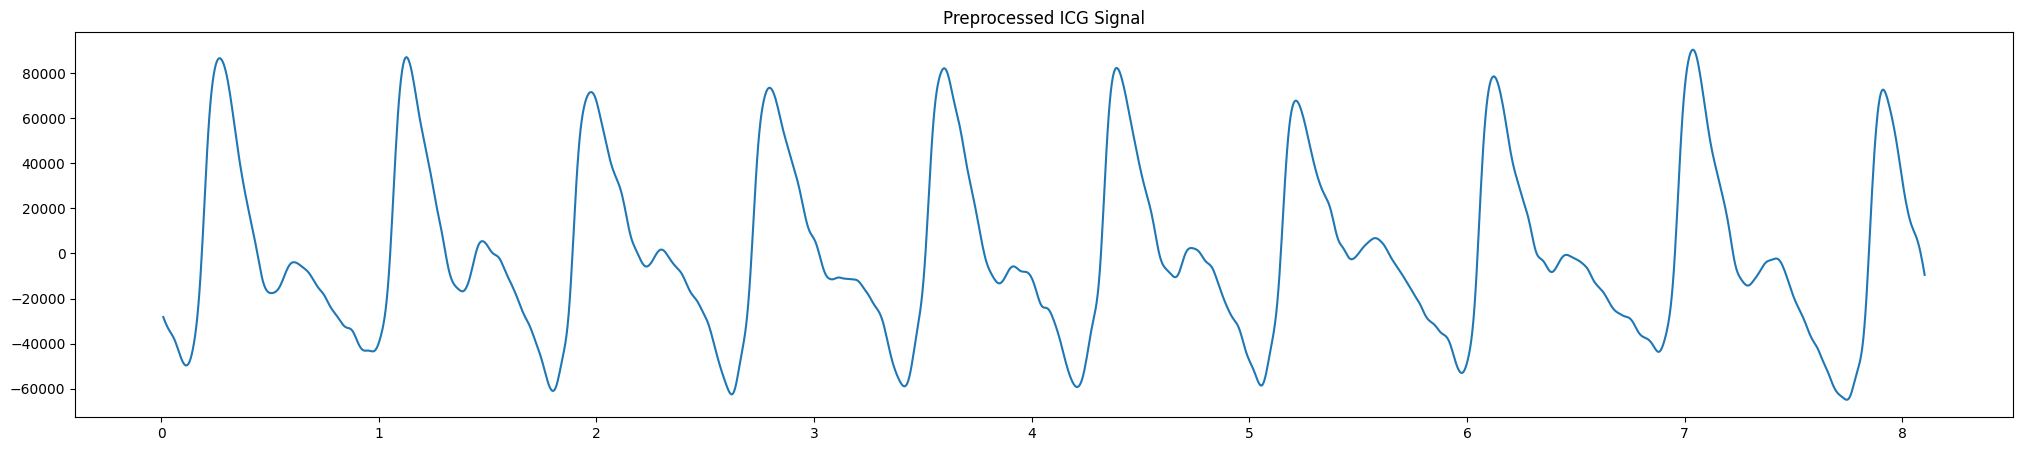

In [ ]:
def preprocess_icg_detrend(icg_data, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2):
    # Bandpass filter
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    icg_bandpassed = filtfilt(b, a, icg_data)

    # Baseline estimation using SG and subtraction
    baseline = savgol_filter(icg_bandpassed, window_length=sg_window, polyorder=sg_poly)
    icg_detrended = icg_bandpassed - baseline

    # Plot
    plt.figure(figsize=(25, 5))
    plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.4)
    plt.plot(icg_time, icg_bandpassed, label='Band-passed ICG', alpha=0.7)
    plt.plot(icg_time, icg_detrended, label='Detrended ICG', linewidth=2)
    plt.legend()
    plt.title("ICG Signal: Raw, Band-passed, and Baseline-corrected")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return icg_detrended

icg_detrended = preprocess_icg_detrend(icg_bandpassed, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2)
plt.figure(figsize=(25, 5))
plt.plot(icg_time, icg_detrended)
plt.title("Preprocessed ICG Signal")

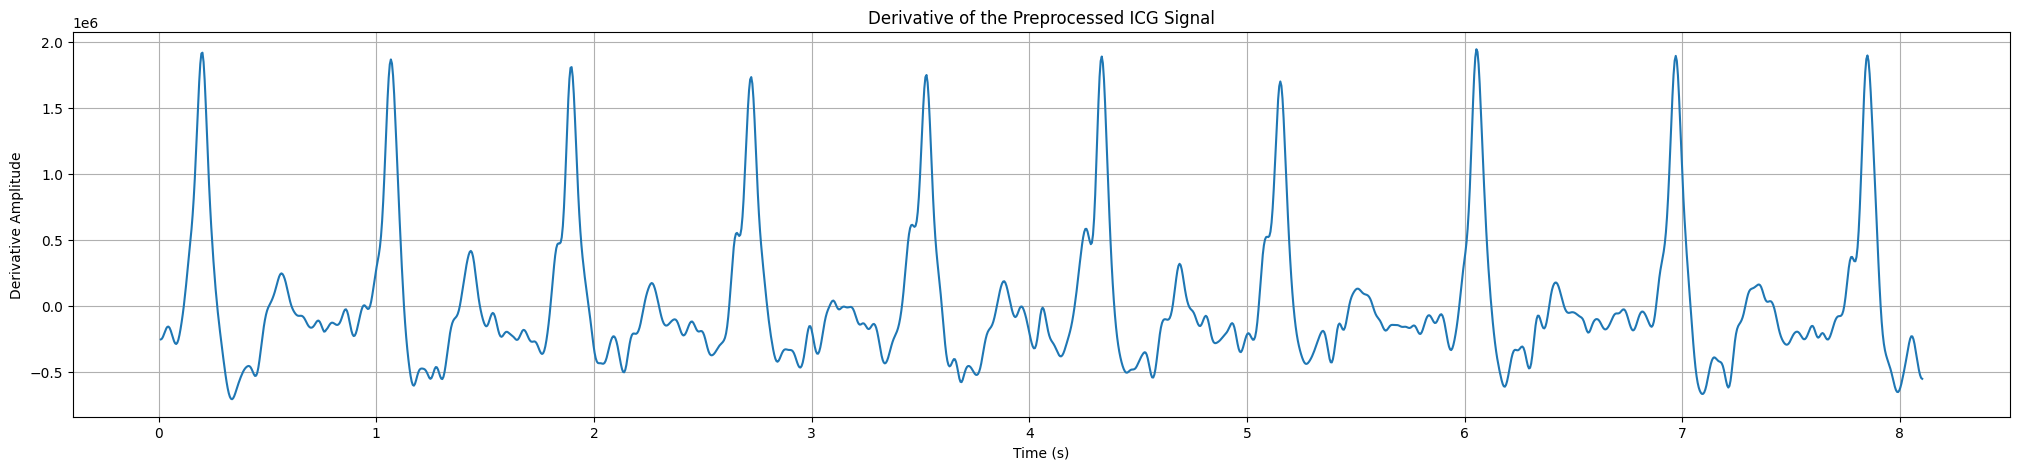

In [ ]:
# Calculate the derivative using central difference method
dt = np.mean(np.diff(icg_time))
dz_dt = np.gradient(icg_detrended, dt)

# Plot the derivative
plt.figure(figsize=(25, 5))
plt.plot(icg_time, dz_dt)
plt.title("Derivative of the Preprocessed ICG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Derivative Amplitude")
plt.grid(True)
plt.show()


Conclusion: We apply band-pass filtering followed by Savitzky-Golay (SG) filtering to detrend the impedance signal. After obtaining the cleaned signal, we compute its derivative to enhance characteristic point detection.

##ECG Preprocessing

We have 4 ECG signals with different sampling frequencies.

Sampling Frequency ECG 1: 198.71 Hz
Sampling Frequency ECG 2: 43797.38 Hz
Sampling Frequency ECG 3: 136.00 Hz
Sampling Frequency ECG 4: 495.90 Hz


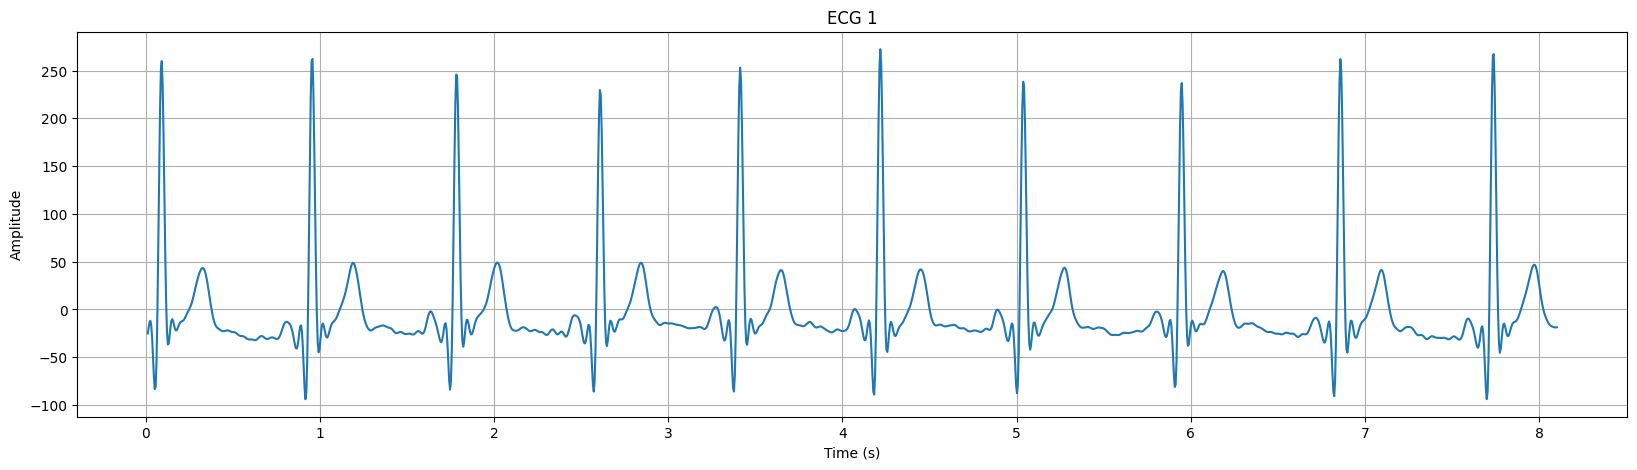

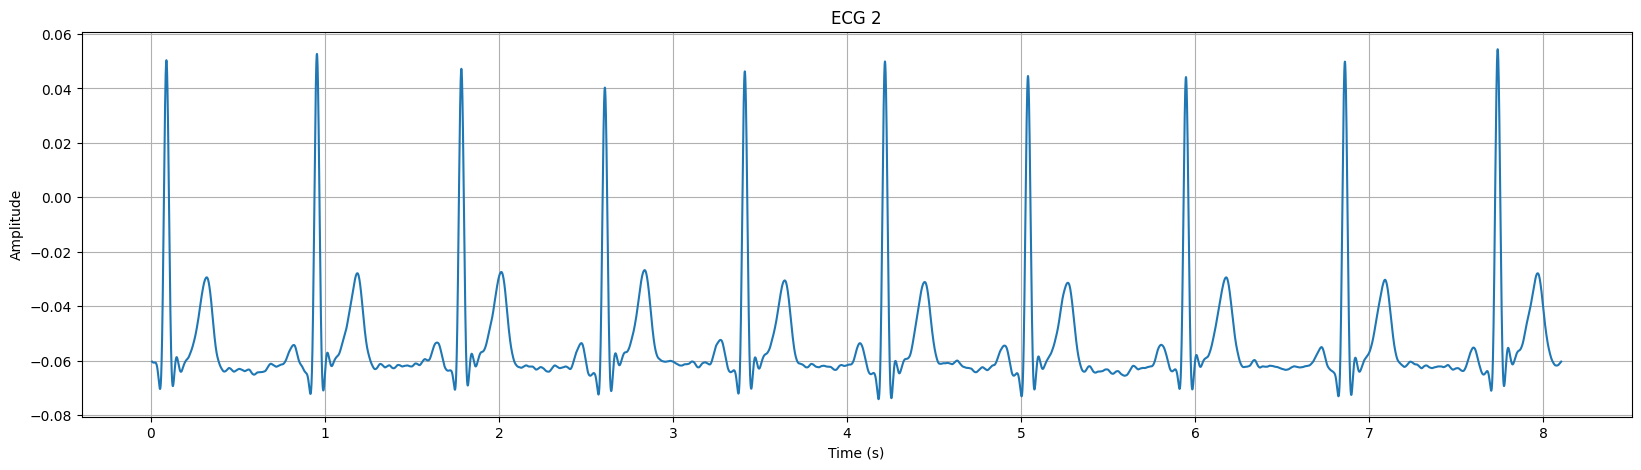

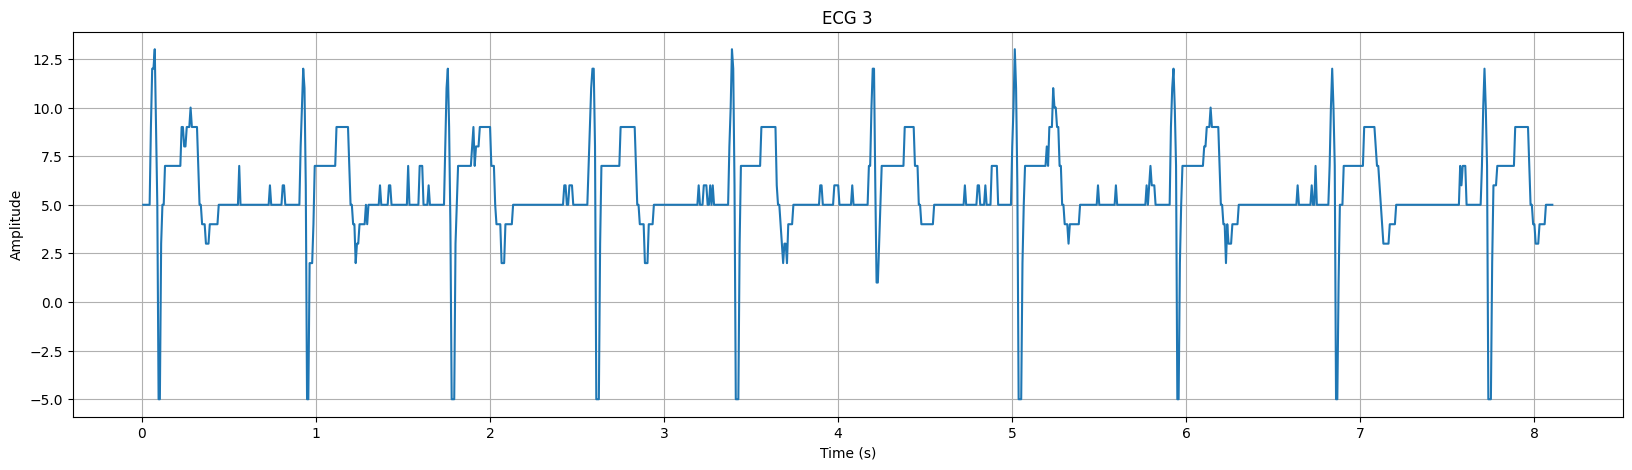

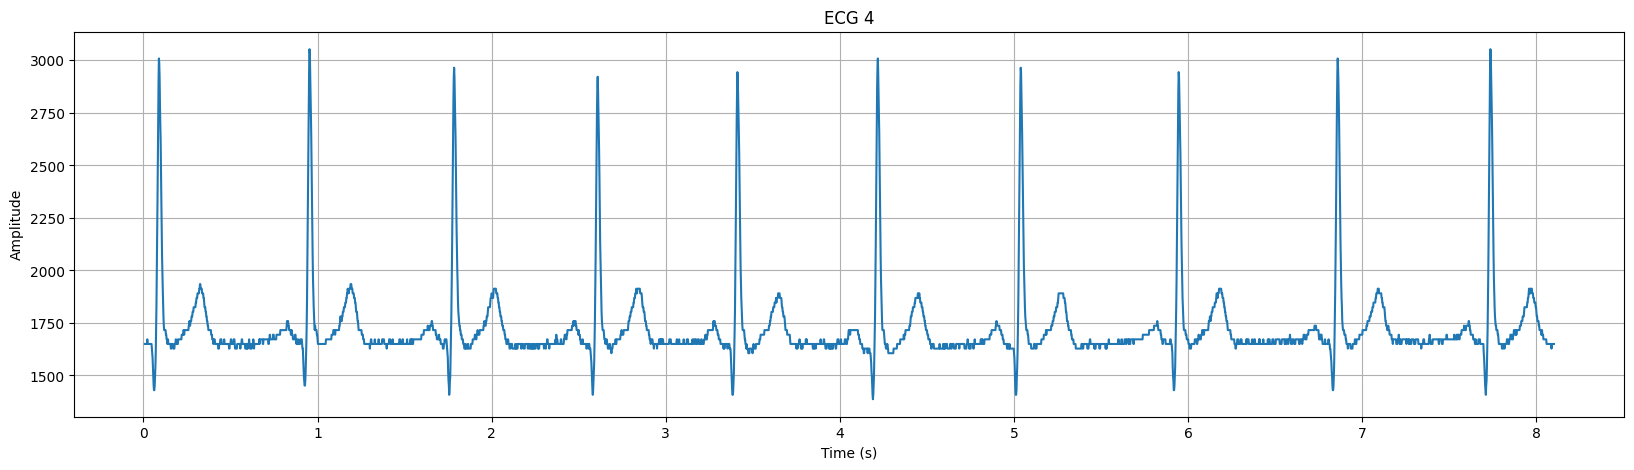

In [ ]:
ecg_1 = measures[0, 1]
ecg_2 = measures[0, 2]
ecg_3 = measures[0, 3]
ecg_4 = measures[0, 4]

ecg_1_time = ecg_1['time'][0, 0].flatten()
ecg_1_data = ecg_1['data'][0, 0].flatten()

ecg_2_time = ecg_2['time'][0, 0].flatten()
ecg_2_data = ecg_2['data'][0, 0].flatten()

ecg_3_time = ecg_3['time'][0, 0].flatten()
ecg_3_data = ecg_3['data'][0, 0].flatten()

ecg_4_time = ecg_4['time'][0, 0].flatten()
ecg_4_data = ecg_4['data'][0, 0].flatten()

# Plot ECG 1
plt.figure(figsize=(20, 5))
plt.plot(ecg_1_time, ecg_1_data)
plt.title('ECG 1')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot ECG 2
plt.figure(figsize=(20, 5))
plt.plot(ecg_2_time, ecg_2_data)
plt.title('ECG 2')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot ECG 3
plt.figure(figsize=(20, 5))
plt.plot(ecg_3_time, ecg_3_data)
plt.title('ECG 3')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot ECG 4
plt.figure(figsize=(20, 5))
plt.plot(ecg_4_time, ecg_4_data)
plt.title('ECG 4')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

def get_sampling_frequency(time_array):
    time_diffs = np.diff(time_array)
    avg_time_step = np.mean(time_diffs)
    fs = 1 / avg_time_step
    return fs

fs_1 = get_sampling_frequency(ecg_1_time)
fs_2 = get_sampling_frequency(ecg_2_time)
fs_3 = get_sampling_frequency(ecg_3_time)
fs_4 = get_sampling_frequency(ecg_4_time)

print(f"Sampling Frequency ECG 1: {fs_1:.2f} Hz")
print(f"Sampling Frequency ECG 2: {fs_2:.2f} Hz")
print(f"Sampling Frequency ECG 3: {fs_3:.2f} Hz")
print(f"Sampling Frequency ECG 4: {fs_4:.2f} Hz")

We observe that ECG channel 1 often exhibits baseline drift. To address this, we apply a band-pass filter. The recommended range by the American Heart Association is 0.05 Hz to 150 Hz. However, we encounter a limitation:

ValueError: Digital filter critical frequencies must be 0 < Wn < 1

This error occurs because the high cutoff frequency (150 Hz) exceeds the valid range relative to the Nyquist frequency (nyq = fs_3 / 2). The butter function requires the cutoff frequencies to be normalized between 0 and 1, where 1 corresponds to the Nyquist frequency.


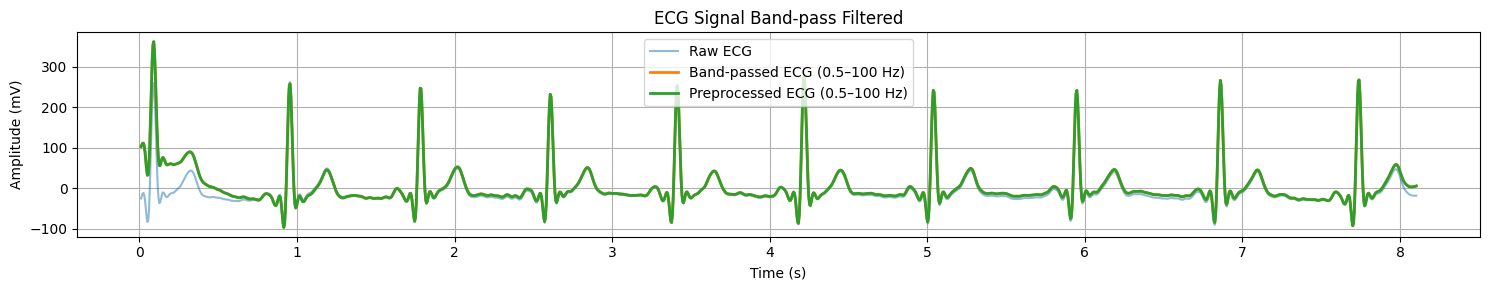

In [ ]:
from scipy.signal import iirnotch

def notch_filter(data, fs, freq=50, quality_factor=30):
    b, a = iirnotch(freq, quality_factor, fs)
    return filtfilt(b, a, data)

ecg_1_bandpassed = bandpass(ecg_1_data, fs_1, 0.5,45)
ecg_1_preprocessed = notch_filter(ecg_1_bandpassed, fs_1, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_1_time, ecg_1_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_1_time, ecg_1_bandpassed, label='Band-passed ECG (0.5–100 Hz)', linewidth=2)
plt.plot(ecg_1_time, ecg_1_preprocessed, label='Preprocessed ECG (0.5–100 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We observe that ecg_1_bandpassed and ecg_1_preprocessed are identical, indicating that the signal likely did not contain power line interference and therefore required no additional cleaning in that frequency range.

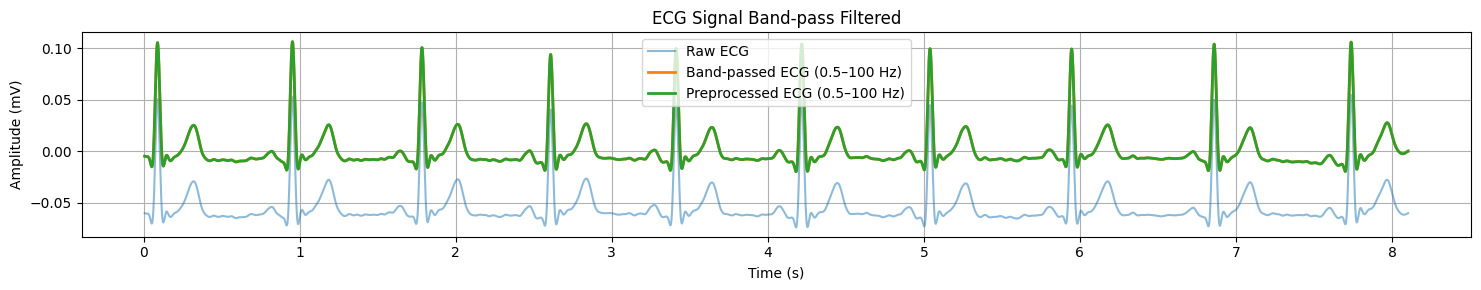

In [ ]:
ecg_2_bandpassed = bandpass(ecg_2_data, fs_2, 0.5,100)
ecg_2_preprocessed = notch_filter(ecg_2_bandpassed, fs_2, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_2_time, ecg_2_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_2_time, ecg_2_bandpassed, label='Band-passed ECG (0.5–100 Hz)', linewidth=2)
plt.plot(ecg_2_time, ecg_2_preprocessed, label='Preprocessed ECG (0.5–100 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

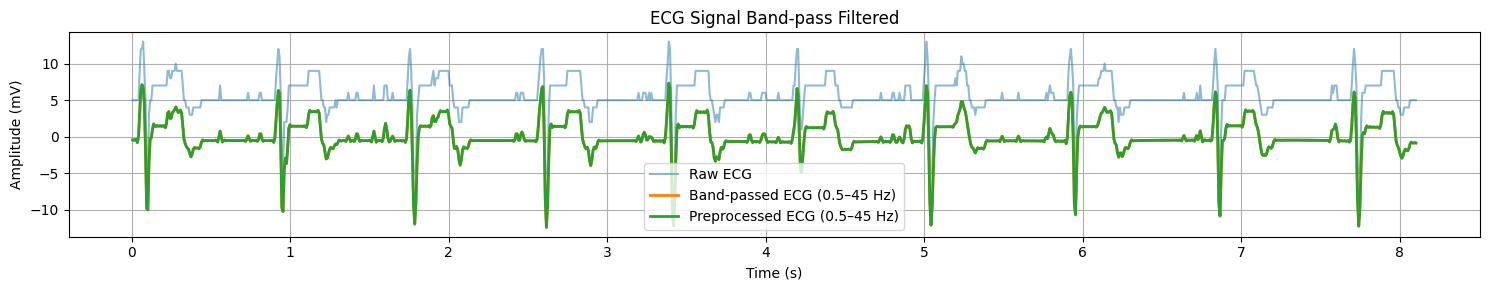

In [ ]:
ecg_3_bandpassed = bandpass(ecg_3_data, fs_3, 0.5, 45)
ecg_3_preprocessed = notch_filter(ecg_3_bandpassed, fs_3, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_3_time, ecg_3_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_3_time, ecg_3_bandpassed, label='Band-passed ECG (0.5–45 Hz)', linewidth=2)
plt.plot(ecg_3_time, ecg_3_preprocessed, label='Preprocessed ECG (0.5–45 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


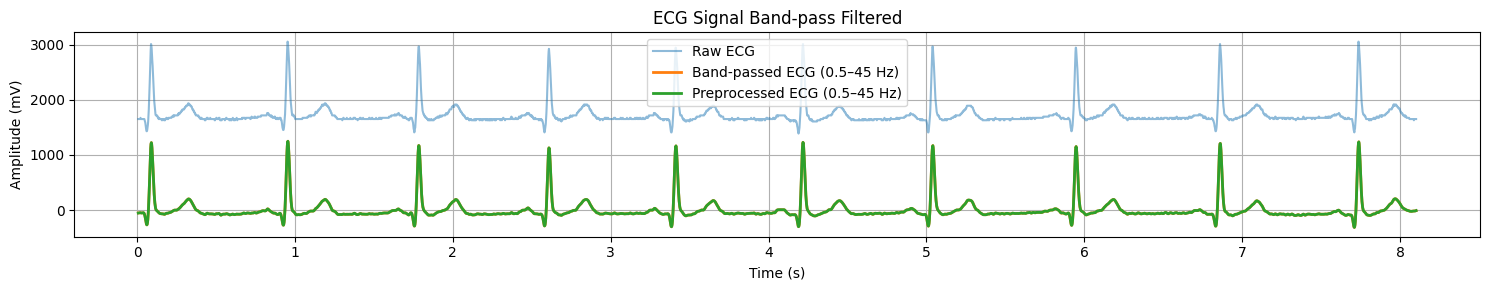

In [ ]:
ecg_4_bandpassed = bandpass(ecg_4_data, fs_4, 0.5, 45)
ecg_4_preprocessed = notch_filter(ecg_4_bandpassed, fs_4, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_4_time, ecg_4_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_4_time, ecg_4_bandpassed, label='Band-passed ECG (0.5–45 Hz)', linewidth=2)
plt.plot(ecg_4_time, ecg_4_preprocessed, label='Preprocessed ECG (0.5–45 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


We normalize with Z score so we can plot it with ICG.

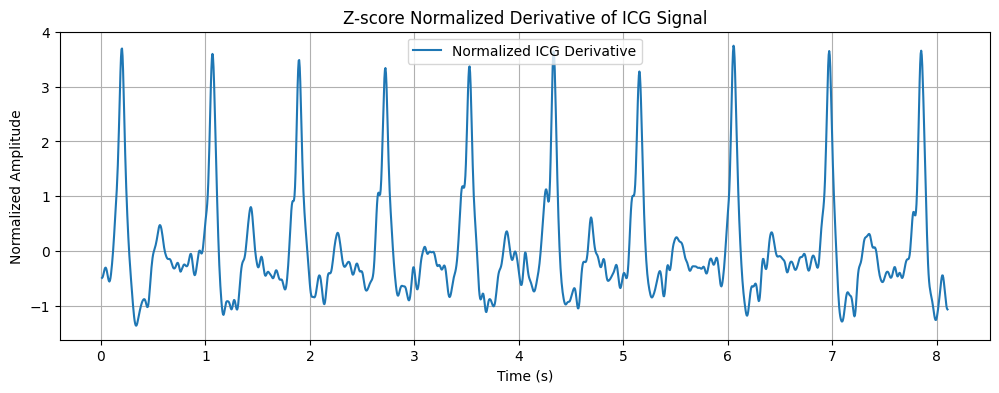

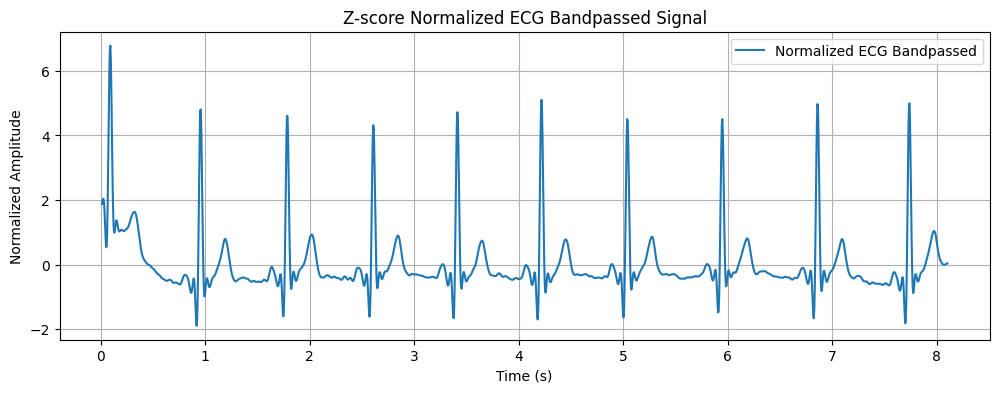

In [ ]:
scaler_icg = StandardScaler()
dz_dt_norm = scaler_icg.fit_transform(dz_dt.reshape(-1, 1))

scaler_ecg = StandardScaler()
ecg_1_bandpassed_normalized = scaler_ecg.fit_transform(ecg_1_bandpassed.reshape(-1, 1))

# Plot normalized ICG derivative
plt.figure(figsize=(12, 4))
plt.plot(icg_time, dz_dt_norm, label='Normalized ICG Derivative')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.title('Z-score Normalized Derivative of ICG Signal')
plt.grid(True)
plt.legend()
plt.show()

# Plot normalized ECG
plt.figure(figsize=(12, 4))
plt.plot(ecg_1_time, ecg_1_bandpassed_normalized, label='Normalized ECG Bandpassed')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.title('Z-score Normalized ECG Bandpassed Signal')
plt.grid(True)
plt.legend()
plt.show()


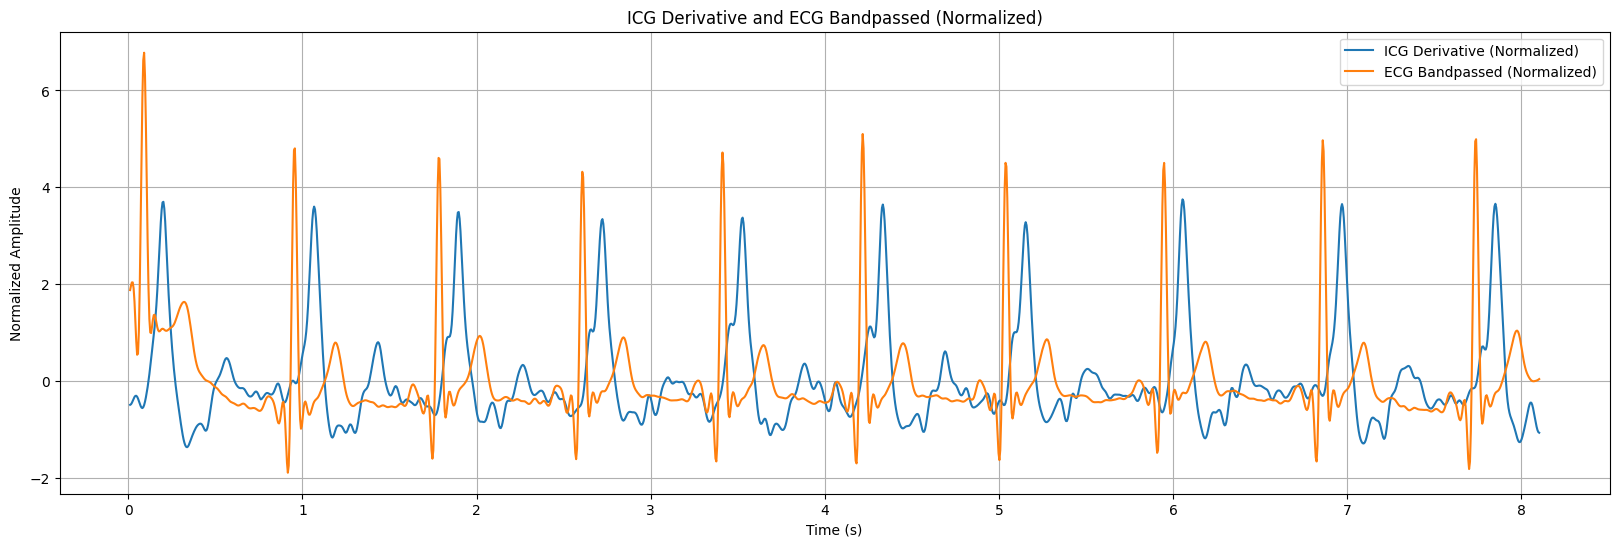

In [ ]:
plt.figure(figsize=(20, 6))
plt.plot(icg_time, dz_dt_norm, label='ICG Derivative (Normalized)')
plt.plot(ecg_1_time, ecg_1_bandpassed_normalized, label='ECG Bandpassed (Normalized)')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.title('ICG Derivative and ECG Bandpassed (Normalized)')
plt.legend()
plt.grid(True)
plt.show()


# ECG R peaks

[0.32806249 1.18836953 2.06880071 2.94420086 3.80953893 4.67990805
 5.53015302 6.36530488 7.23064296 8.11107414]


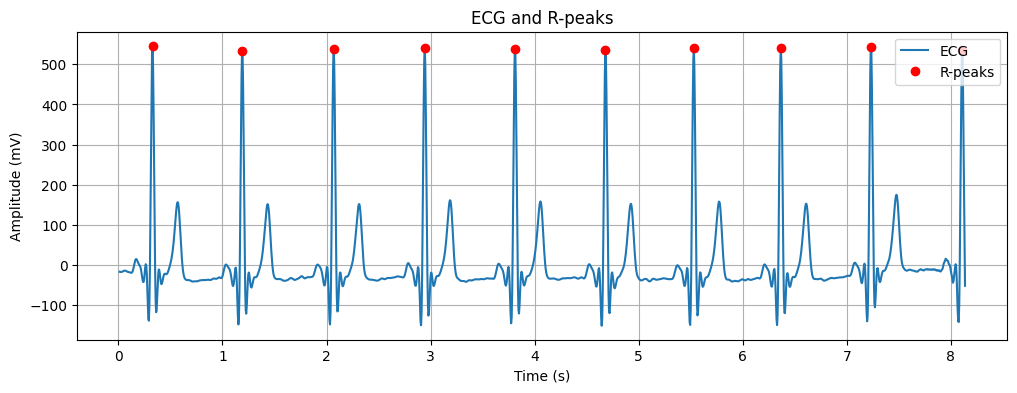

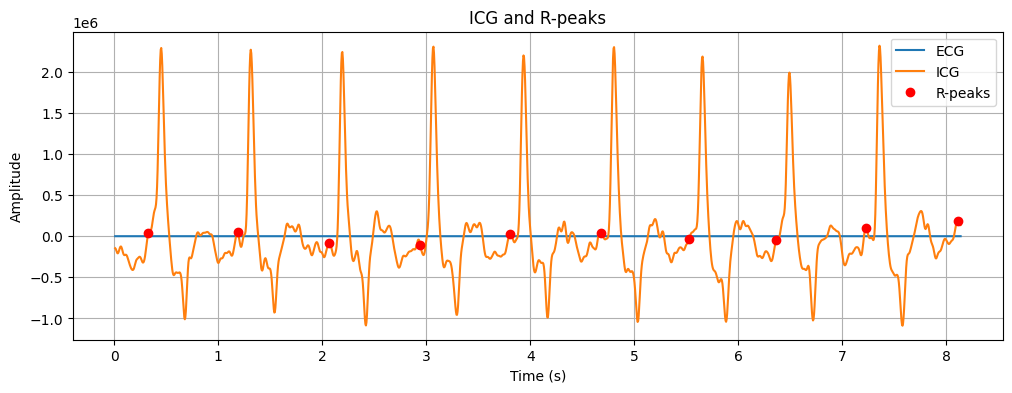

In [ ]:
rpeaks = measures[2,1]
rpeaks_time = rpeaks['time'][0,0].flatten()
rpeaks_values = rpeaks['data'][0,0].flatten()
#print(rpeaks_values)

# numpy array?
rpeaks_times = np.array(rpeaks_values)
print(rpeaks_times)

# find the closest points to the time second
rpeaks_index = np.array([np.argmin(np.abs(ecg_1_time - t)) for t in rpeaks_times])

plt.figure(figsize=(12, 4))
plt.plot(ecg_1_time, ecg_1_preprocessed, label='ECG')
plt.plot(ecg_1_time[rpeaks_index], ecg_1_preprocessed[rpeaks_index], 'ro', label='R-peaks') #put the r peaks in red points
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(ecg_1_time, ecg_1_preprocessed,label='ECG')
plt.plot(icg_time, dz_dt, label='ICG')
plt.plot(icg_time[rpeaks_index], dz_dt[rpeaks_index], 'ro', label='R-peaks') #put the r peaks in red points, also it puts it in the amplitude where the signal is
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()


We see that ECG is much more flat because it's not scaled well, we normalise between 0 and 1 to see them properly

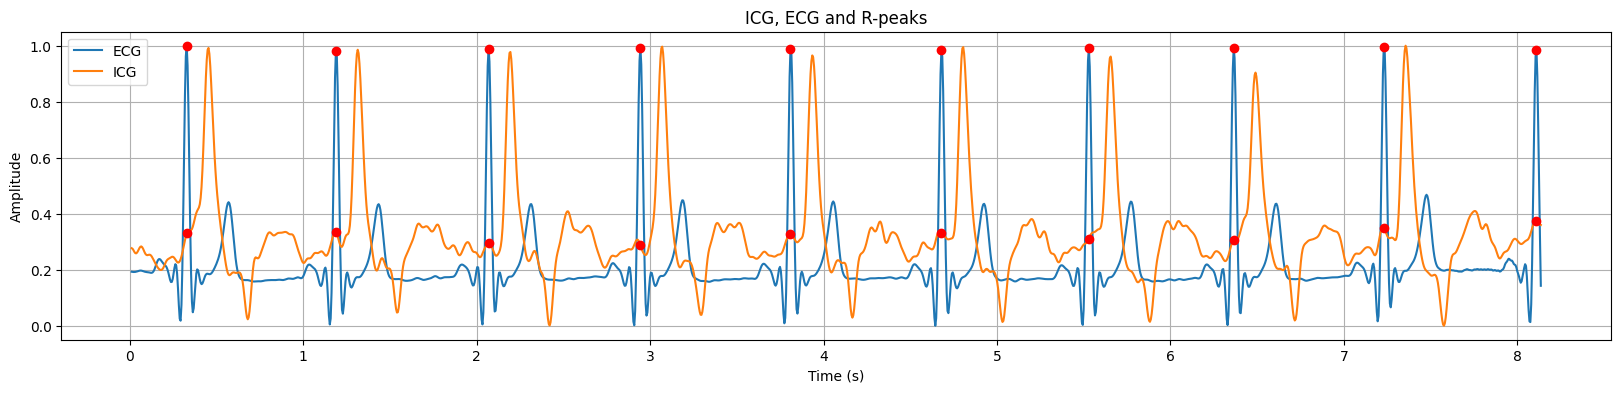

In [ ]:
def normalize(signal):
    return (signal - np.min(signal)) / (np.max(signal) - np.min(signal))

ecg_norm = normalize(ecg_1_preprocessed)
icg_norm = normalize(dz_dt)

plt.figure(figsize=(20, 4))
plt.plot(ecg_1_time, ecg_norm, label='ECG')
plt.plot(icg_time, icg_norm, label='ICG')
plt.plot(ecg_1_time[rpeaks_index], ecg_norm[rpeaks_index], 'ro')
plt.plot(icg_time[rpeaks_index], icg_norm[rpeaks_index],'ro')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG, ECG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()


# Signal correlation (Pearson's test)

In [ ]:
results = []

# 1. ICG preprocessed vs ECG preprocessed
r, p = pearsonr(icg_detrended, ecg_1_preprocessed)
results.append(["ICG Preprocessed", "ECG Preprocessed", r, p])

# 2. ICG Raw vs ECG Raw
r, p = pearsonr(icg_data, ecg_1_data)
results.append(["ICG Raw", "ECG Raw", r, p])

# 3. ICG Raw vs ECG Preprocessed
r, p = pearsonr(icg_data, ecg_1_preprocessed)
results.append(["ICG Raw", "ECG Preprocessed", r, p])

# 4. ICG Preprocessed vs ECG Raw
r, p = pearsonr(icg_detrended, ecg_1_data)
results.append(["ICG Preprocessed", "ECG Raw", r, p])

# 5. ICG Bandpassed vs ECG Raw
r, p = pearsonr(icg_bandpassed, ecg_1_data)
results.append(["ICG Bandpassed", "ECG Raw", r, p])

# 6. ICG Bandpassed vs ECG Preprocessed
r, p = pearsonr(icg_bandpassed, ecg_1_preprocessed)
results.append(["ICG Bandpassed", "ECG Preprocessed", r, p])

# 7. ICG Bandpassed vs ECG Bandpassed
r, p = pearsonr(icg_bandpassed, ecg_1_bandpassed)
results.append(["ICG Bandpassed", "ECG Bandpassed", r, p])

# Create DataFrame
df = pd.DataFrame(results, columns=["ICG Signal", "ECG Signal", "Pearson's r", "P-value"])
df_rounded = df.copy()
df_rounded[["Pearson's r", "P-value"]] = df_rounded[["Pearson's r", "P-value"]].round(6)

print(df_rounded)



         ICG Signal        ECG Signal  Pearson's r   P-value
0  ICG Preprocessed  ECG Preprocessed     0.175111  0.000000
1           ICG Raw           ECG Raw     0.028988  0.245196
2           ICG Raw  ECG Preprocessed     0.067751  0.006555
3  ICG Preprocessed           ECG Raw     0.179019  0.000000
4    ICG Bandpassed           ECG Raw     0.144639  0.000000
5    ICG Bandpassed  ECG Preprocessed     0.154410  0.000000
6    ICG Bandpassed    ECG Bandpassed     0.154398  0.000000


Weak but statistically significant positive correlation (r ≈ 0.16, p < 0.001) between the preprocessed ICG and ECG signals, suggesting a modest linear relationship after preprocessing.

Negligible and non-significant correlation (r ≈ 0.04, p ≈ 0.14) in raw data.

The preprocessing enhances the relationship of the signals. However, the overall low correlation values suggest that ICG and ECG signals are not strongly correlated.

# ICG delineation algorithm

## C point detection

In [ ]:
rr_int = np.diff(rpeaks_times) #rr intervals
print(rr_int)

[0.86030704 0.88043118 0.87540015 0.86533808 0.87036911 0.85024497
 0.83515186 0.86533808 0.88043118]


In [ ]:
def find_c_peaks(icg, rr_int):
    """
    Finds the maximum value (C peak) within each RR interval in the ICG signal.

    Input:
        icg: The preprocessed ICG signal.
        rr_int:  The RR intervals (beat-to-beat intervals).

    Output:
        A list of C peak values.
    """
    c_peaks = []
    start_index = 0
    for rr in rr_int:
        end_index = start_index + int(round(rr * fs)) # Convert seconds to samples
        if end_index >= len(icg):
            end_index = len(icg) -1 #handle edge cases where the end_index exceeds the signal length
        c_peaks.append(np.max(icg[start_index:end_index]))
        start_index = end_index
    return c_peaks

c_peaks_values = find_c_peaks(icg_detrended, rr_int)
print("C-peak values:", c_peaks_values)

C-peak values: [np.float64(102058.91042397928), np.float64(80588.92895905457), np.float64(76357.08944751587), np.float64(80881.70719818851), np.float64(82149.34434068875), np.float64(92198.45688664667), np.float64(89898.21461775659), np.float64(84839.8371206068), np.float64(97244.11532962619)]


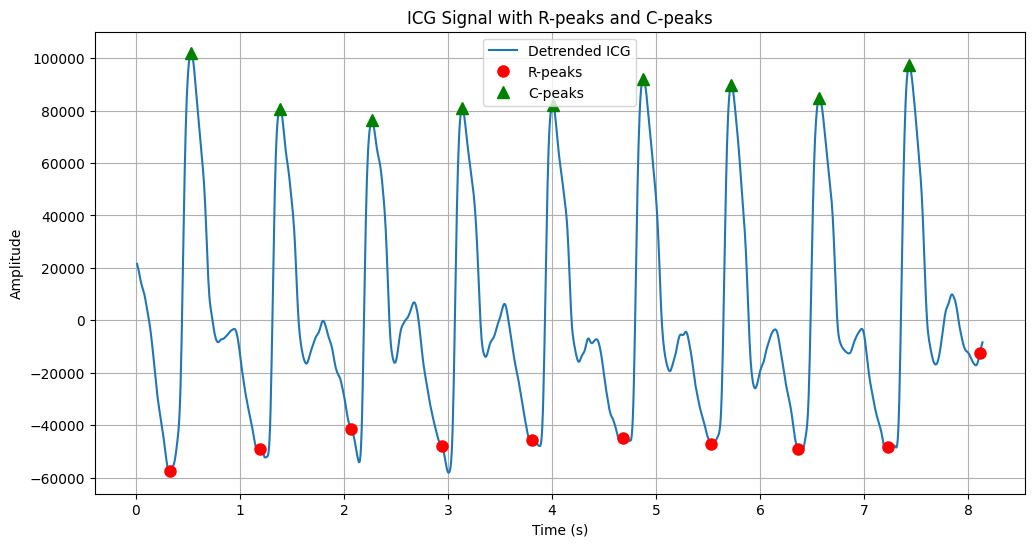

[np.float64(0.5293038984227874), np.float64(1.3845799045733536), np.float64(2.270042122705709), np.float64(3.1353801995168737), np.float64(4.005749311658331), np.float64(4.876118423799795), np.float64(5.721332359289768), np.float64(6.566546294779744), np.float64(7.4318843715909075)]
[np.float64(102058.91042397928), np.float64(80588.92895905457), np.float64(76357.08944751587), np.float64(80881.70719818851), np.float64(82149.34434068875), np.float64(92198.45688664667), np.float64(89898.21461775659), np.float64(84839.8371206068), np.float64(97244.11532962619)]


In [ ]:
# Find the indices of the R-peaks in the ICG signal's time vector
rpeaks_index = np.array([np.argmin(np.abs(icg_time - t)) for t in rpeaks_times])

# Plot the C peaks over the ICG
plt.figure(figsize=(12, 6))
plt.plot(icg_time, icg_detrended, label='Detrended ICG')
plt.plot(icg_time[rpeaks_index], icg_detrended[rpeaks_index], 'ro', markersize=8, label='R-peaks')

# Calculate RR intervals (if not already defined)
rr_int = np.diff(rpeaks_times)

C_peak_times = []
C_peaks_values = []  # Added to store amplitude values
start_index = 0
for i, rr in enumerate(rr_int):
    end_index = start_index + int(round(rr * fs))
    if end_index >= len(icg_detrended):
        end_index = len(icg_detrended) - 1
    current_max_idx = start_index + np.argmax(icg_detrended[start_index:end_index])
    C_peak_times.append(icg_time[current_max_idx])
    C_peaks_values.append(icg_detrended[current_max_idx])  # Store amplitude
    start_index = rpeaks_index[i+1]  # Move to next R-peak index

# Plot C-peaks (fixed the string quote and variable name)
plt.plot(C_peak_times, C_peaks_values, 'g^', markersize=8, label='C-peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG Signal with R-peaks and C-peaks')
plt.legend()
plt.grid(True)
plt.show()
print(C_peak_times)
print(C_peaks_values)

## B points

Options:
- the B point is detected as the sign change within 20% and 65% of the R–C interval window of the ICG first derivative [ReBeat]

- 15% response from the baseline [14 de Systematic Variability]

- equation that relates the R peak of the electrocardiography (ECG) signal and the C peak of the dZ/dt signal; RB = 1.233RE -0.0032RE2 - 31.59 [11 de Systematic Variability]

- From what I see is that the B point is the lowest point between R and C

### ReBeat algorithm to find the B point

In [ ]:
def find_b_point(sig, Cpos, CAmpl, Afrac, Fs, Bslope1, Bslope2):
    """
    Find the B point in the ICG signal.

    Inputs:
    - sig: ICG signal (numpy array or list), e.g., icg_detrended
    - Cpos: Time of C peak (in seconds)
    - CAmpl: Amplitude at C peak
    - Afrac: Fraction of C amplitude to define BlimR threshold
    - Fs: Sampling frequency (Hz)
    - Bslope1: Slope threshold for steep descent
    - Bslope2: Slope threshold for strong positive slope

    Returns:
    - BlimL_time: Left limit of B window (in seconds)
    - BlimR_time: Right limit of B window (in seconds)
    """
    # Convert seconds to sample index
    C_idx = int(Cpos * Fs)
    offset_samples = int(0.08 * Fs)
    BlimL_idx = C_idx - offset_samples

    threshold = Afrac * CAmpl
    BlimR_idx = None
    for i in range(C_idx, BlimL_idx, -1):
        if sig[i] <= threshold:
            BlimR_idx = i
            break

    if BlimR_idx is None:
        BlimR_idx = BlimL_idx

    # Convert back to seconds for output
    BlimL_time = BlimL_idx / Fs
    BlimR_time = BlimR_idx / Fs

    return BlimL_time, BlimR_time

# Afrac = 0.5
# Bslope1 = 0.11
# Bslope2 = 0.08

i = 0  # example: first C peak

# Extract the single C peak time and value
Cpos = C_peak_times[i]
CAmpl = C_peaks_values[i]

# Make sure your signal is a NumPy array
sig = np.array(icg_detrended)

# Now call the function
BlimL, BlimR = find_b_point(sig, Cpos, CAmpl, 0.5, fs, 0.11, 0.08)

print("BlimL (s):", BlimL)
print("BlimR (s):", BlimR)


In [ ]:
import numpy as np
from scipy.signal import argrelextrema

def find_B_points(sig, C_pos_list, C_Ampl_list, A_frac=0.5, B_slope1=0.11, B_slope2=0.08, Fs=1000):
    """
    Detect B points for a list of C points.

    Parameters:
        sig         : 1D numpy array of the ICG signal
        C_pos_list  : list or array of indices for C points (can be float, will be cast to int)
        C_Ampl_list : list or array of amplitudes at C points
        A_frac      : fraction of C amplitude to determine BlimR
        B_slope1    : slope threshold for the first pass
        B_slope2    : slope threshold for the second pass
        Fs          : sampling frequency in Hz

    Returns:
        List of B point indices (same length as C_pos_list)
    """
    sig_deriv = np.gradient(sig)
    B_points = []

    for C_pos, C_Ampl in zip(C_pos_list, C_Ampl_list):
        C_pos = int(round(C_pos))  # convert to integer index
        BlimL = max(0, C_pos - int(0.08 * Fs))

        A_thresh = A_frac * C_Ampl
        BlimR = C_pos
        for i in range(C_pos, BlimL, -1):
            if sig[i] <= A_thresh:
                BlimR = i
                break

        # First pass: local min or steep slope
        local_mins = argrelextrema(sig[BlimL:BlimR + 1], np.less)[0] + BlimL
        found = False
        for i in range(BlimR, BlimL, -1):
            if i in local_mins or abs(sig_deriv[i]) > B_slope1:
                B_points.append(i)
                found = True
                break

        if found:
            continue

        # Second pass: relaxed slope
        for i in range(BlimR, BlimL, -1):
            if sig_deriv[i] > B_slope2:
                B_points.append(i)
                found = True
                break

        if not found:
            Bmin = np.argmin(sig[BlimL:BlimR + 1]) + BlimL
            B_points.append(Bmin)

    return B_points

C_indices = (np.array(C_peak_times) * fs).astype(int)

Bpoints = find_B_points(icg_detrended, C_indices, C_peaks_values,
                        A_frac=0.5, B_slope1=0.11, B_slope2=0.08, Fs=fs)

print("Detected B points:", Bpoints/fs)


####We want to know if the B points are well detected, we use R-B segment = PEP

In [ ]:
import numpy as np

r = np.array([0.13436714, 1.00060419, 1.88195003, 2.74818708, 3.6043516,
              4.48569744, 5.37207954, 6.24335285, 7.14484374, 8.03122584])

b = np.array([0.26188562, 1.11805015, 2.00443225, 2.8706693,3.72179756,4.6031434,5.56506943, 6.36583507, 7.33783362])


# Compute the difference for the first 9 pairs
difference = b - r[:9]
print("Difference R-B (PEP):", difference*1000)

PEP = [105, 100, 110, 110, 95, 100, 105, 95, 100]
diff = PEP - difference*1000
print(diff)

### B point according to other algorithms


##### RB = 1.233RE -0.0032RE2 - 31.59
- equation that relates the R peak of the electrocardiography (ECG) signal and the C peak of the dZ/dt signal; RB = 1.233RE -0.0032RE2 - 31.59 [11 from Systematic Variability paper]

The results suggest that the B point occurs 31.35 ms before the R point

In [ ]:
rc_diff = C_peak_times - rpeaks_times[:len(C_peak_times)]

rb_diff = 1.233 * rc_diff - 0.0032 * rc_diff**2 - 31.59
print("Differences between R-peak and B point times:")
rb_diff

##### B point is detected as the sign change within 20% and 65% of the R–C interval window of the ICG first derivative

In [ ]:
b_points = []

for r_time, c_time in zip(rpeaks_times[:len(C_peak_times)], C_peak_times):
    rc_interval = c_time - r_time
    start = r_time + 0.20 * rc_interval
    end = r_time + 0.65 * rc_interval

    # Indices in ICG signal that fall within the 20%-65% window
    window_idx = np.where((icg_time >= start) & (icg_time <= end))[0]
    #True where the time is within the interval [start, end], and False elsewhere.

    found = False
    for i in window_idx[:-1]:
        y1, y2 = icg_detrended[i], icg_detrended[i+1] #	get the amplitudes of the ICG signal at index i and i+1
        if y1 * y2 < 0:  # sign change = zero crossing
            t1, t2 = icg_time[i], icg_time[i+1]
            # Linear interpolation to estimate zero-crossing time
            zero_cross = t1 - y1 * (t2 - t1) / (y2 - y1)
            b_points.append(zero_cross)
            found = True
            break

    if not found:
        b_points.append(np.nan)  # No zero-crossing found

b_points = np.array(b_points)
print(b_points) #and the amplitudes are 0 because its the zero crossing point

In [ ]:
rpeaks_index = np.array([np.argmin(np.abs(icg_time - t)) for t in rpeaks_times])
plt.figure(figsize=(12, 6))
plt.plot(icg_time, icg_detrended, label='ICG')
plt.plot(icg_time[rpeaks_index], icg_detrended[rpeaks_index], 'ro', markersize=8, label='R-peaks')

# Plot C-peaks
plt.plot(C_peak_times, C_peaks_values, 'g^', markersize=8, label='C-peaks')

# Plot B points (zero-crossing points)
plt.plot(b_points, np.zeros_like(b_points), 'bo', markersize=8, label='B-points')  # Blue circles for B-points

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG Signal with R-peaks, C-peaks, and B-points')
plt.legend()
plt.grid(True)

#obtain the avo info
avo_icg_all = measures[3,1]
avo_icg = avo_icg_all[0,0]
# avo_stc = measures[3,2] # avo_echo = measures[3,3] # avo_ppg = measures[3,4] #only the first one had more than 1 point
#print(avo_icg['data'])

#avc info
avc_icg_all = measures[5,1]
avc_icg = avc_icg_all[0,0]

fs_echo = 136
fs_icg = 200
for time_point in avo_icg['data']:
    plt.axvline(x=int(time_point), color='r', linestyle='--', label='AVO')
#for time_point in avc_icg['data']:
 #   plt.axvline(x=int(time_point), color='b', linestyle='--', label='AVC')

In [ ]:
pep_1 = measures[4,1]
pep_2 = measures[4,2]
pep_3 = measures[4,3]
pep_4 = measures[4,4]

RB_interval = b_points-(rpeaks_values[:len(b_points)]) #if we assume Q occurs 20 ms before the R peak

print(RB_interval*1000)
print(pep_1['data'])
#print(pep_2['data']) #empty
#print(pep_3['data']) #empty
#print(pep_4['data']) #empty

We use the 15% above the baseline approach.

For this, we estimate the baseline again using SG, just like before

In [ ]:
sg_window=301
sg_poly=2

baseline_det = savgol_filter(icg_detrended, window_length=sg_window, polyorder=sg_poly)
threshold_detrended = baseline_det * 1.15

# detect the first time point where the signal exceeds the threshold
b_point_15 = np.nan #initialize variable
for i in range(len(icg_detrended)):
    if icg_detrended[i] >= threshold_detrended[i]:
        b_point_15 = icg_time[i]  # Save the time when the signal exceeds the threshold
        break

print(f"The B point (15% above baseline) occurs at: {b_point_15} seconds")

#### X point detection

The X-point detection is based on the observation that onset of steep rise in ICG towards the end of the T wave of ECG is closely aligned with the AVC. The lowest point in the first one-third of the C–C segment of the ICG is marked as the Xi point (initial estimate of X) and the highest point in the C–C interval is marked as the O point. The first difference of the ICG during the first half of the Xi–O segment is scanned for locating the points with a change of sign. Slopes of the line segments joining each of these points with the O point are calculated and the point with the highest slope is marked as the X point. An example of X-point detection is shown in figure 4. [11]

1107
1616
     Correlation (r)       p-value
0          -0.002568  9.178565e-01
1          -0.005682  8.194742e-01
2           0.001574  9.495989e-01
3           0.030921  2.141137e-01
4           0.030284  2.236965e-01
..               ...           ...
268        -0.146867  2.999878e-09
269        -0.110764  8.084127e-06
270        -0.013878  5.772055e-01
271         0.045735  6.605518e-02
272        -0.033365  1.800489e-01

[273 rows x 2 columns]
Maximum r: 0.6541830828527275 at index 147 with p-value: 5.342195978767871e-198


<ipython-input-30-20c6107a4c90>:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=int(time_point * fs_icg), color='r', linestyle='--', label='AVO')
<ipython-input-30-20c6107a4c90>:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=int(time_point * fs_icg), color='b', linestyle='--', label='AVC')
<ipython-input-30-20c6107a4c90>:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=int(time_point * fs_icg), color='r', linestyle='-

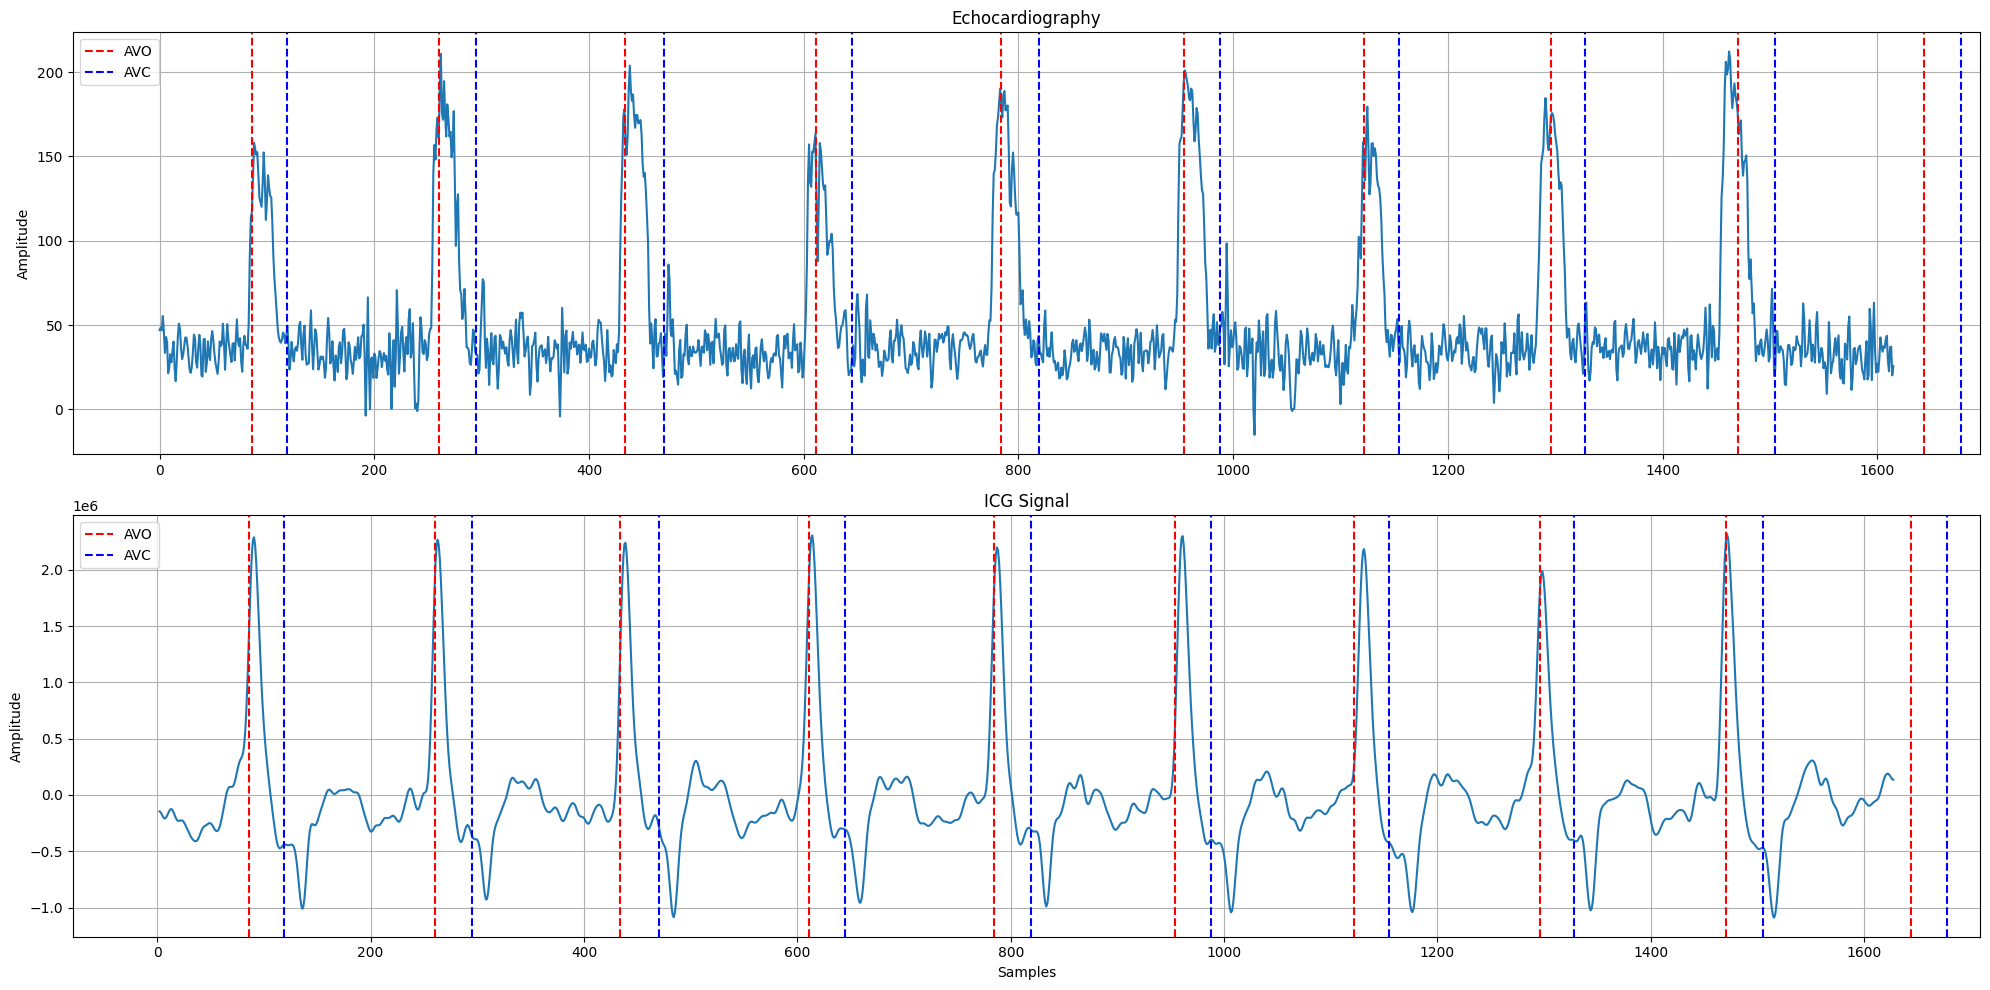

In [ ]:
#obtain the avo info
avo_icg_all = measures[3,1]
avo_icg = avo_icg_all[0,0]
# avo_stc = measures[3,2] # avo_echo = measures[3,3] # avo_ppg = measures[3,4] #only the first one had more than 1 point
#print(avo_icg['data'])

#avc info
avc_icg_all = measures[5,1]
avc_icg = avc_icg_all[0,0]

echo = measures[1,3]
echo_time = echo['time']
echo_data = echo['data']
echo_value = echo_data[0, 0]

# we obtain all the lines in echo
echo_all_lines = []
for i in range(0,273): #we know the depth is 273
    echo_line = echo_value[i, :, 0]
    echo_all_lines.append(echo_line)

echo_all_lines = np.array(echo_all_lines)

#we see that the length of echo and icg don't match because they have different fs
print(len(echo_all_lines[35]))
print(len(dz_dt))

fs_echo = 136
fs_icg = 200

r_echo = []
p_echo = []
all_echo_resampled = []

for j in range(len(echo_all_lines)):
    echo_resampled = resample(echo_all_lines[j], len(dz_dt)) #we resample the echo signal to the icg length
    r, p = pearsonr(dz_dt, echo_resampled)
    r_echo.append(r)
    p_echo.append(p)
    all_echo_resampled.append(echo_resampled)

df = pd.DataFrame({
    'Correlation (r)': r_echo,
    'p-value': p_echo
})

print(df)

# we want to see the maximum correlation with the icg to select the most relevant line
max_r = max(r_echo)
max_index = r_echo.index(max_r)
corresponding_p = p_echo[max_index]

print(f"Maximum r: {max_r} at index {max_index} with p-value: {corresponding_p}")
# for 59146237/59146237_s0000002.mat --> Maximum r: 0.44308128368744776 at index 65 with p-value: 2.427494472173909e-78
# if we check the signal at 65 we see that it is the line with the most info (intuitively)
plt.figure(figsize=(20, 10))

plt.subplot(2, 1, 1)
plt.plot(all_echo_resampled[max_index])
plt.title('Echocardiography')
plt.ylabel('Amplitude')
plt.grid(True)

for time_point in avo_icg['data']:
    plt.axvline(x=int(time_point * fs_icg), color='r', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=int(time_point * fs_icg), color='b', linestyle='--', label='AVC')

#  legend without duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.subplot(2, 1, 2)
plt.plot(icg_time * fs_icg, dz_dt)
plt.title('ICG Signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)

for time_point in avo_icg['data']:
    plt.axvline(x=int(time_point * fs_icg), color='r', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=int(time_point * fs_icg), color='b', linestyle='--', label='AVC')

#  legend without duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()